# Business Understanding

The objective of this project is to analyze the company's sales performance and identify opportunities for business growth.

Business Questions:

1. What is the total sales revenue?
2. What is the total profit generated?
3. Which products contribute the most to sales?
4. Which product categories generate the highest profit?
5. Which region has the best sales performance?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from google.colab import files

uploaded = files.upload()

Saving SampleSuperstore.csv to SampleSuperstore.csv


In [10]:
import pandas as pd

df = pd.read_csv(
    'SampleSuperstore.csv',
    encoding='latin1'
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [11]:
df.shape

(9994, 21)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# Data Understanding

The dataset contains **9,994 transaction records** and **21 features** related to customer orders, products, sales performance, discounts, and profitability.

### Data Structure

- 15 categorical variables (object)
- 3 numerical variables (float)
- 3 numerical identifier variables (integer)

### Key Variables

- Sales: Revenue generated from each transaction
- Profit: Profit earned from each transaction
- Discount: Discount applied to the order
- Category: Product category
- Sub-Category: Detailed product classification
- Region: Geographic sales region
- Order Date: Date when the order was placed

The dataset is suitable for analyzing sales performance, profitability, product demand, and regional business trends.

## Initial Findings

The dataset appears to be complete, with no missing values detected across all 21 columns.

The data includes both business performance metrics (Sales, Profit, Discount) and descriptive information about customers, products, and regions, providing a strong foundation for sales analysis.

In [13]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [14]:
df.duplicated().sum()

np.int64(0)

# Data Cleaning

The dataset was assessed for data quality issues, including missing values and duplicate records.

### Missing Values

No missing values were found across all 21 columns.

### Duplicate Records

No duplicate records were identified in the dataset.

### Data Quality Assessment

The dataset is clean and complete, making it suitable for exploratory data analysis and business performance evaluation without requiring additional preprocessing.

In [16]:

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")

Total Sales: $2,297,200.86
Total Profit: $286,397.02


# KPI Analysis

**Total Sales:** $2,297,200.86

**Total Profit:** $286,397.02

The company generated strong revenue and maintained positive profitability during the analyzed period.

In [17]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales

,Sales
Category,
Technology,836154.0330
Furniture,741999.7953
Office Supplies,719047.0320


# Sales by Category

Top Sales Category: Technology ($836,154.03)

Second Highest Category: Furniture ($741,999.80)

Third Highest Category: Office Supplies ($719,047.03)

Technology generated the highest sales revenue and was the main contributor to the company's overall sales performance. Furniture and Office Supplies also contributed significantly, indicating a relatively balanced sales distribution across categories.

In [18]:

category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
category_profit

,Profit
Category,
Technology,145454.9481
Office Supplies,122490.8008
Furniture,18451.2728


# Category Profit Analysis

Technology generated the highest profit of $145,454.95, making it the most profitable category in the business.

Office Supplies ranked second with a profit of $122,490.80 and showed strong profitability despite having lower sales than Technology.

Furniture produced the lowest profit at $18,451.27, which is significantly lower than the other categories. This suggests that Furniture products may be associated with higher costs, larger discounts, or lower profit margins.

The analysis indicates that Technology is the strongest category in both sales and profitability, while Furniture may require further investigation to improve financial performance.

In [19]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales

,Sales
Region,
West,725457.8245
East,678781.2400
Central,501239.8908
South,391721.9050


# Regional Sales Analysis

The West region generated the highest sales revenue at $725,457.82, making it the strongest-performing region in terms of sales.

The East region ranked second with total sales of $678,781.24, followed by the Central region with $501,239.89.

The South region recorded the lowest sales revenue at $391,721.91.

These results suggest that the West and East regions are the primary contributors to company revenue, while the South region may present opportunities for market expansion and sales improvement.

# Business Insights

Technology is the strongest-performing category, leading both sales and profit generation.

Office Supplies demonstrated strong profitability and contributed significantly to overall business profit.

Furniture generated substantial sales revenue but produced relatively low profit, indicating potential margin or discount-related challenges.

The West and East regions were the major contributors to total sales, accounting for a large portion of company revenue.

The South region showed the lowest sales performance and may require additional sales and marketing efforts to increase revenue.

# Conclusion

Total Sales: $2,297,200.86

Total Profit: $286,397.02

Technology was the best-performing category in both sales and profit.

Office Supplies showed strong profitability.

Furniture generated high sales but relatively low profit.

West and East were the strongest sales regions.

South recorded the lowest sales performance.

The company achieved positive overall profitability and has opportunities to improve profit margins and regional sales growth.

# Recommendations

Focus on expanding Technology products, as they generate both high sales and high profit.

Investigate pricing strategies, discounts, and operational costs within the Furniture category to improve profit margins.

Maintain and strengthen sales efforts in the West and East regions, which are the company's strongest markets.

Develop targeted marketing campaigns and customer acquisition strategies in the South region to increase revenue growth.

Monitor category-level profitability regularly to ensure that sales growth translates into sustainable profit growth.

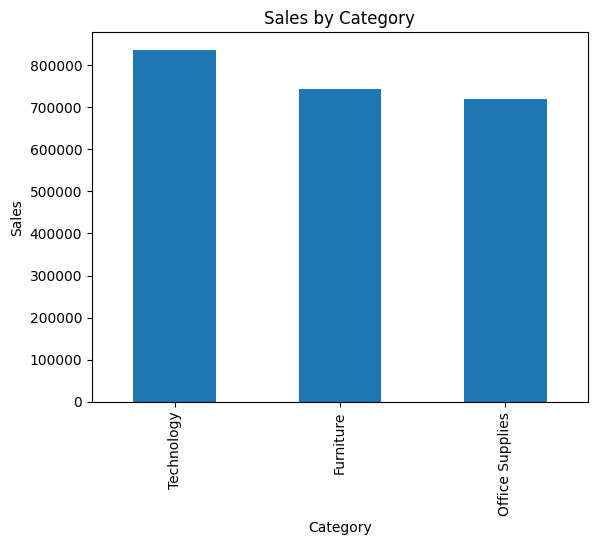

In [20]:
import matplotlib.pyplot as plt

category_sales.plot(kind='bar')

plt.title('Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

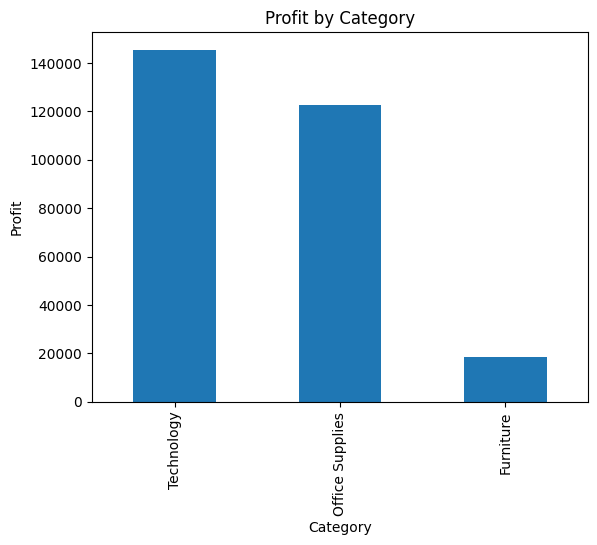

In [21]:
category_profit.plot(kind='bar')

plt.title('Profit by Category')
plt.xlabel('Category')
plt.ylabel('Profit')
plt.show()

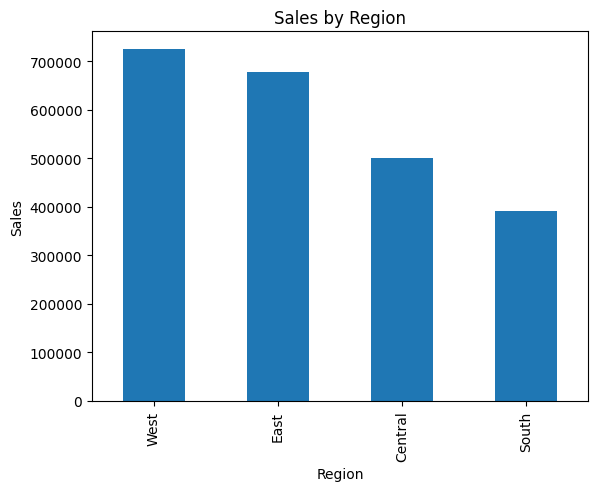

In [22]:

region_sales.plot(kind='bar')

plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

# Executive Summary

This project analyzed 9,994 sales transactions from the Superstore dataset.

Total Sales: $2,297,200.86

Total Profit: $286,397.02

Technology generated the highest sales and profit.

Furniture produced high sales but lower profit compared to other categories.

West was the highest-performing region in terms of sales.

South recorded the lowest sales revenue.

The analysis provides insights that can support business growth and profitability improvement.